# XSensor vs Pressure Plate

Comparing load distribution and force readings between the AMTI pressure plate and XSensor insoles across three trials: static standing, weight shifting, and walking.

In [278]:
# FUNCTIONS FOR IMPORTING DATA FROM CSV FILES
import pandas as pd

#Function for Importing Pressure Plate Data from a CSV file
def import_pressure_plate_data(file_path):
    df = pd.read_csv(file_path, skiprows=4, usecols=[0, 3, 10])  # Sample = col0, FZ1 = col3 (right), FZ2 = col10 (left)
    df.columns = ['sample', 'right_foot', 'left_foot']  # Rename columns for clarity
    return df

#Function for Importing Pressure Plate Walking Data (3 plates) from a CSV file
def import_pressure_plate_walking_data(file_path):
    df = pd.read_csv(file_path, skiprows=4, usecols=[0, 3, 10, 17])  # Sample, FZ1, FZ2, FZ3
    df.columns = ['sample', 'pp1', 'pp2', 'pp3']
    return df

#Function for Importing Xsensor Data from a CSV file
def import_xsensor_data(file_path):
    df = pd.read_csv(file_path, skiprows=4, usecols=[0, 3, 4])  # Frame = col0, Left Insole = col3, Right Insole = col4
    df.columns = ['sample', 'left_foot', 'right_foot']  # Rename columns for clarity
    df[['left_foot', 'right_foot']] = df[['left_foot', 'right_foot']].round(2)  # Round the insole data to 2 decimal places
    return df

In [279]:
# FUNCTION FOR PLOTTING THE DATA
import matplotlib.pyplot as plt
plt.rcParams.update({
    "figure.facecolor": "#212121",  # Lighter dark (Charcoal)
    "axes.facecolor": "#212121",    # Match axes to figure
    "axes.edgecolor": "#706e6e",    # Subtle border
    "axes.labelcolor": "#E0E0E0",   # Soft white text
    "xtick.color": "#B0B0B0",       # Grey ticks
    "ytick.color": "#B0B0B0",
    "grid.color": "#c2bebe",        # Light dark grid lines
    "grid.linestyle": "--",         # Dashed grid for "pretty" look
    "grid.alpha": 0.5,              # Semi-transparent grid
    "text.color": "#E0E0E0",
    "axes.prop_cycle": plt.cycler(color=['#80daeb', '#ff9f9b', '#9df0a3', '#ffcc80']) # Pretty palette
})

def plot_data(df, title):
    x = df['sample']
    y_right = df['right_foot']
    y_left = df['left_foot']
    plt.figure(figsize=(12, 3.6))
    plt.plot(x, y_right, label='Right Foot', color='blue')
    plt.plot(x, y_left, label='Left Foot', color='orange')
    plt.fill_between(x, y_right, color='blue', alpha=0.2)
    plt.fill_between(x, y_left, color='orange', alpha=0.2)
    plt.title(title)
    plt.xlabel('Sample')
    plt.ylabel('Estimated Load (N)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid()
    plt.show()

def plot_walking_pp(df, title):
    x = df['sample']
    plt.figure(figsize=(12, 3.6))
    plt.plot(x, df['pp1'], label='PP1 (Plate 1)', color='blue')
    plt.plot(x, df['pp2'], label='PP2 (Plate 2)', color='orange')
    plt.plot(x, df['pp3'], label='PP3 (Plate 3)', color='green')
    plt.fill_between(x, df['pp1'], color='blue', alpha=0.15)
    plt.fill_between(x, df['pp2'], color='orange', alpha=0.15)
    plt.fill_between(x, df['pp3'], color='green', alpha=0.15)
    plt.title(title)
    plt.xlabel('Sample')
    plt.ylabel('Estimated Load (N)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid()
    plt.show()

## Raw Data - Individual Device Readings

Each trial plotted separately for the pressure plate and XSensor, showing left and right foot force over time.

### Static Trial

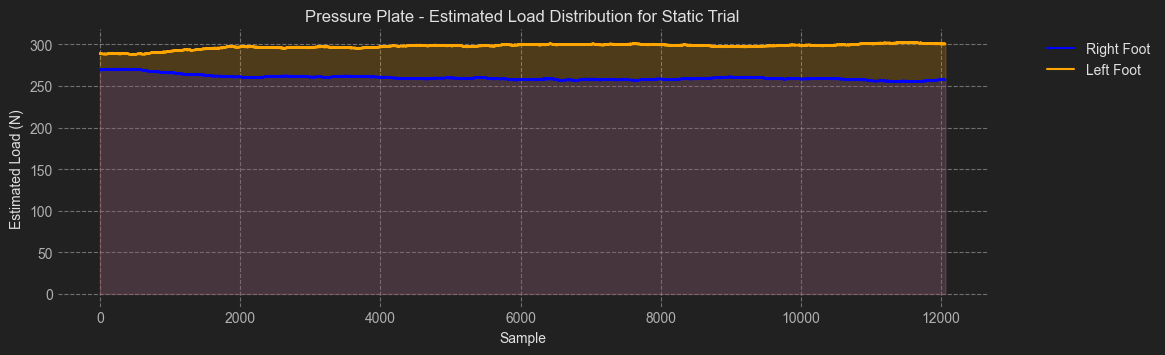

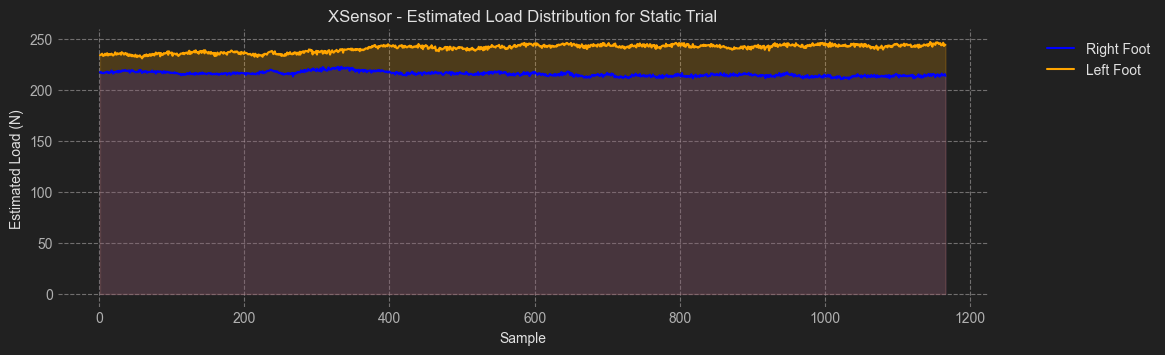

In [280]:
# STATIC TRIAL ANALYSIS

# Import pressure plate and XSensor data for static trial
df_pp_static = import_pressure_plate_data('Pressure_Plate/PP_03_27_26_static.csv')  
df_xs_static = import_xsensor_data('Xsensor/XS_03_27_26_static.csv')

# Display the first few rows of each dataframe
# print("Static Pressure Plate Data:")
# print(df_pp_static.head(5))

# print("\nStatic Xsensor Data:")
# print(df_xs_static.head(5))

plot_data(df_pp_static, 'Pressure Plate - Estimated Load Distribution for Static Trial')

plot_data(df_xs_static, 'XSensor - Estimated Load Distribution for Static Trial')

### Weight Shift Trial

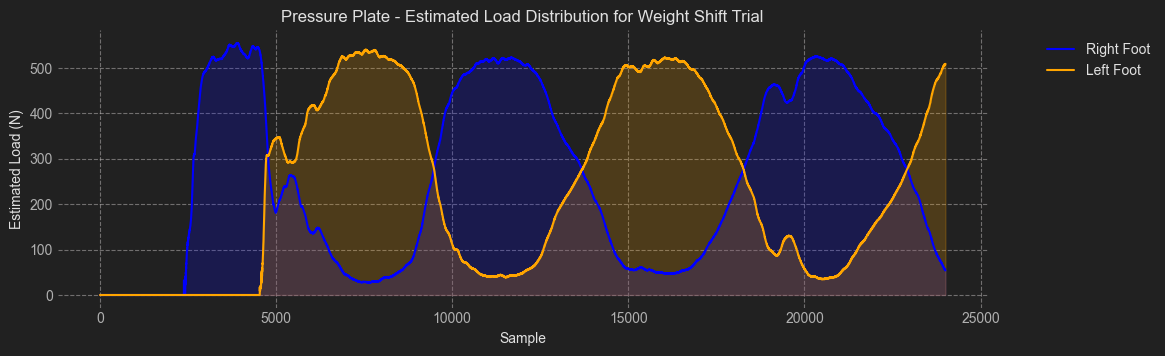

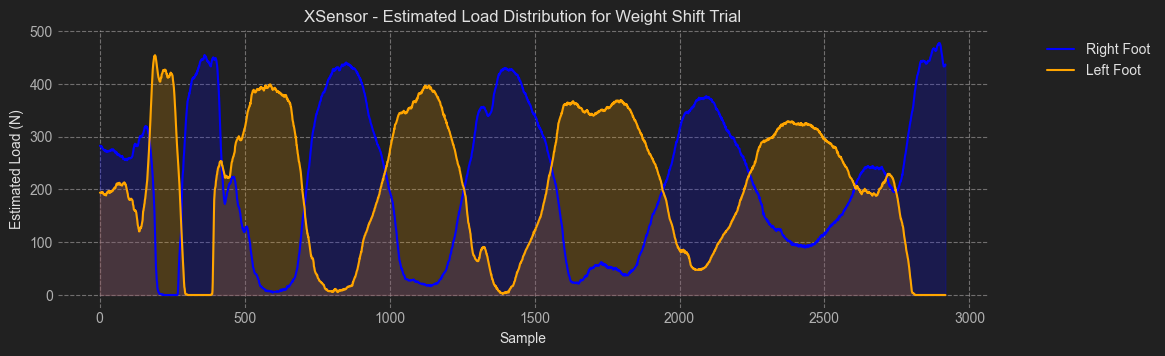

In [281]:
# WALKING TRIAL ANALYSIS

# Import pressure plate and XSensor data for static trial
df_pp_weight_shift = import_pressure_plate_data('Pressure_Plate/PP_03_27_26_weight_shift.csv')  
df_xs_weight_shift = import_xsensor_data('Xsensor/XS_03_27_26_weight_shift.csv')

# Display the first few rows of each dataframe
# print("Weight Shift Pressure Plate Data:")
# print(df_pp_weight_shift.head(5))

# print("\nWeight Shift Xsensor Data:")
# print(df_xs_weight_shift.head(5))

plot_data(df_pp_weight_shift, 'Pressure Plate - Estimated Load Distribution for Weight Shift Trial')
plot_data(df_xs_weight_shift, 'XSensor - Estimated Load Distribution for Weight Shift Trial')

### Walking Trial

The walking trial uses 3 pressure plates. The subject walked forward stepping PP1 → PP2 → PP3, turned around, then stepped PP2 → PP1. This means **PP1 and PP3 always recorded the same foot**, and **PP2 recorded the other foot**. It is unknown which foot (left or right) started on PP1, but for comparison with XSensor we assume **PP1 & PP3 = Left Foot** and **PP2 = Right Foot**.

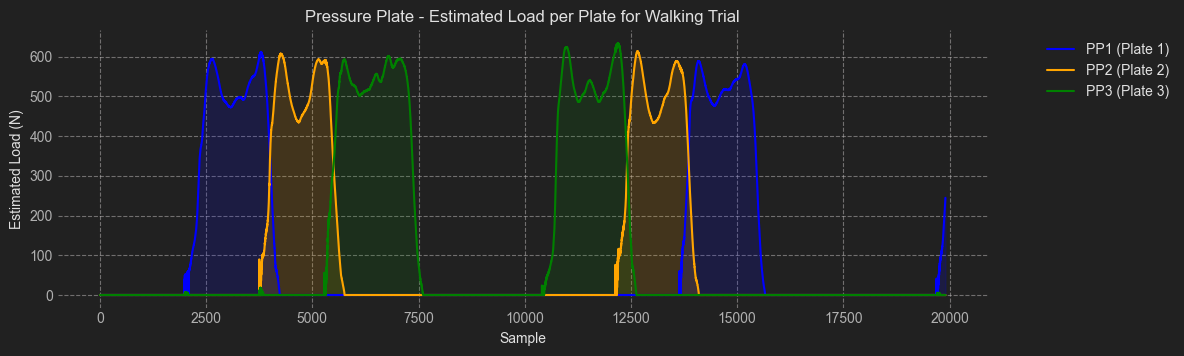

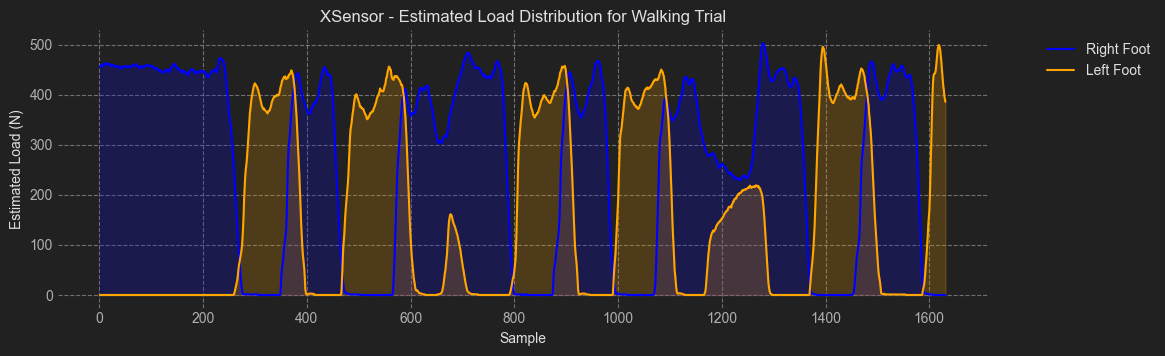

In [282]:
# WALKING TRIAL ANALYSIS
# Walking trial uses 3 pressure plates:
#   PP1 and PP3 = same foot (person walked PP1 -> PP2 -> PP3, turned, PP2 -> PP1)
#   PP2 = other foot
#   Unknown which foot started, so we label by plate rather than left/right

df_pp_walking = import_pressure_plate_walking_data('Pressure_Plate/PP_03_27_26_walking.csv')
df_xs_walking = import_xsensor_data('Xsensor/XS_03_27_26_walking.csv')

plot_walking_pp(df_pp_walking, 'Pressure Plate - Estimated Load per Plate for Walking Trial')
plot_data(df_xs_walking, 'XSensor - Estimated Load Distribution for Walking Trial')

## Data Processing & Comparison

To compare the two devices fairly, we need to handle three things:

1. Match the sampling rates - The pressure plate records at 2400 Hz and the XSensor at 150 Hz. That's 16x more data points from the PP. We downsample the PP by averaging every 16 samples into 1, bringing it down to 150 Hz.

2. Align the recordings in time - Two different people pressed "start" on each device, so there's a timing offset. We use derivative-based cross-correlation to find the best alignment (see below).

3. Trim to the overlapping window - After aligning, we cut both signals to only the time period where both were actively recording.

### Finding the Best Alignment

We use **derivative-based cross-correlation** on the individual foot signals. Instead of correlating the raw force values, we correlate the *rate of change* (derivative) of each foot's signal. This aligns on **when forces change** (transitions, heel strikes, weight shifts) rather than what the values are.

This approach is more robust than raw-signal correlation because:
- **Weight shift**: The raw signal is periodic, so raw correlation can lock onto the wrong cycle. The derivative captures the *timing of transitions*, which is more distinctive.
- **Walking**: The PP reads zero between plate contacts, which distorts raw correlation. The derivative captures the sharp onset/offset of each step.
- **Static**: The signal is nearly flat, so alignment matters less — but the derivative still captures any small balance adjustments.

Before alignment, leading and trailing inactive periods (total force < 50 N) are trimmed from both signals. This removes the ~1 second at the start of the PP recording where the subject had not yet stepped onto the plates.

For each foot, the alignment process:
1. Computes the derivative (sample-to-sample difference) of each signal.
2. Normalizes each derivative (subtract mean, divide by standard deviation).
3. Cross-correlates the PP derivative against the XS derivative — slides one across the other to find where transitions line up best.
4. Sums the left-foot and right-foot correlations — both feet must agree on the offset.
5. Finds the peak — the offset where both signals' transitions overlap best.

### Aligning and Trimming

Once we know the lag (time offset in samples) from the alignment function:

1. Shift the earlier signal - If lag is positive (PP started first), we skip ahead that many samples in the PP data. If negative (XS started first), we skip ahead in the XS data.
2. Trim to equal length - After shifting, one signal may still be longer than the other. We cut both to the length of the shorter one so every time point has data from both devices.
3. Add a time column - Convert sample indices to seconds (dividing by 150 Hz) for plotting.

In [283]:
# FUNCTIONS FOR PROCESSING AND COMPARING DATA
import numpy as np

PP_RATE = 2400   # Pressure plate samples per second
XS_RATE = 150    # XSensor samples per second
DOWNSAMPLE_FACTOR = PP_RATE // XS_RATE  # = 16
ACTIVE_THRESHOLD = 50  # Minimum total force (N) to consider a sample "active"


def downsample_pressure_plate(df):
    """Average every 16 pressure plate samples into 1, bringing it from 2400 Hz down to 150 Hz."""
    foot_cols = [c for c in df.columns if c != 'sample']
    n = (len(df) // DOWNSAMPLE_FACTOR) * DOWNSAMPLE_FACTOR
    df_trimmed = df.iloc[:n].copy()
    df_trimmed['group'] = np.arange(n) // DOWNSAMPLE_FACTOR
    result = df_trimmed.groupby('group')[foot_cols].mean().reset_index(drop=True)
    result.insert(0, 'sample', np.arange(1, len(result) + 1))
    return result


def trim_inactive(df, left_col, right_col, threshold=ACTIVE_THRESHOLD):
    """Remove leading and trailing samples where total force is below threshold."""
    total = df[left_col] + df[right_col]
    active = total[total > threshold].index
    if len(active) == 0:
        return df
    return df.iloc[active[0]:active[-1]+1].reset_index(drop=True)


def find_best_alignment(pp_left, pp_right, xs_left, xs_right):
    """Find time offset using derivative-based cross-correlation.
    
    Aligns on WHEN forces change (transitions, heel strikes, weight shifts)
    rather than the raw force values. This is more robust for:
    - Periodic signals (weight shift) where raw correlation can lock onto wrong cycle
    - Signals with zero regions (walking PP) that distort raw correlation
    """
    def norm(x):
        s = x.std()
        if s < 1e-10:
            return x - x.mean()
        return (x - x.mean()) / s
    
    # Compute derivatives (rate of change) - this captures transitions
    pp_left_d = norm(np.diff(pp_left))
    pp_right_d = norm(np.diff(pp_right))
    xs_left_d = norm(np.diff(xs_left))
    xs_right_d = norm(np.diff(xs_right))
    
    # Cross-correlate derivatives for each foot, then combine
    corr_left = np.correlate(pp_left_d, xs_left_d, mode='full')
    corr_right = np.correlate(pp_right_d, xs_right_d, mode='full')
    combined = corr_left + corr_right
    
    lag = np.argmax(combined) - (len(xs_left_d) - 1)
    return lag


def align_and_trim(df_pp, df_xs, pp_left_col, pp_right_col, xs_left_col='left_foot', xs_right_col='right_foot'):
    """Align the two recordings in time, then trim both to the overlapping region."""
    # Trim inactive regions before alignment so leading zeros don't confuse correlation
    df_pp = trim_inactive(df_pp, pp_left_col, pp_right_col)
    df_xs = trim_inactive(df_xs, xs_left_col, xs_right_col)

    lag = find_best_alignment(
        df_pp[pp_left_col].values, df_pp[pp_right_col].values,
        df_xs[xs_left_col].values, df_xs[xs_right_col].values
    )

    if lag >= 0:
        pp_out = df_pp.iloc[lag:].reset_index(drop=True)
        xs_out = df_xs.copy().reset_index(drop=True)
    else:
        pp_out = df_pp.copy().reset_index(drop=True)
        xs_out = df_xs.iloc[-lag:].reset_index(drop=True)

    min_len = min(len(pp_out), len(xs_out))
    pp_out = pp_out.iloc[:min_len].reset_index(drop=True)
    xs_out = xs_out.iloc[:min_len].reset_index(drop=True)
    pp_out['time'] = np.arange(min_len) / XS_RATE
    xs_out['time'] = np.arange(min_len) / XS_RATE
    return pp_out, xs_out, lag


def compare_trials(pp_raw, xs_raw, trial_name):
    """Full comparison pipeline: downsample, align, plot, and print stats."""
    pp = downsample_pressure_plate(pp_raw)
    pp, xs, lag = align_and_trim(pp, xs_raw, 'left_foot', 'right_foot')

    pp_total = pp['right_foot'] + pp['left_foot']
    xs_total = xs['right_foot'] + xs['left_foot']

    direction = "PP started earlier" if lag >= 0 else "XS started earlier"
    print(f"Alignment: {direction} by {abs(lag)/XS_RATE:.2f}s ({abs(lag)} samples)")
    print(f"Comparing {len(pp)/XS_RATE:.1f}s of overlapping data\n")

    fig, axes = plt.subplots(3, 1, figsize=(12, 10.8))

    axes[0].plot(pp['time'], pp_total, label='Pressure Plate', alpha=0.8)
    axes[0].plot(xs['time'], xs_total, label='XSensor', alpha=0.8)
    axes[0].set_title(f'{trial_name} - Total Estimated Load Over Time')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Force (N)')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].grid()

    axes[1].plot(pp['time'], pp['left_foot'], label='PP Left', color='tab:blue', alpha=0.8)
    axes[1].plot(xs['time'], xs['left_foot'], label='XS Left', color='tab:cyan', alpha=0.8)
    axes[1].plot(pp['time'], pp['right_foot'], label='PP Right', color='tab:orange', alpha=0.8)
    axes[1].plot(xs['time'], xs['right_foot'], label='XS Right', color='tab:red', alpha=0.8)
    axes[1].set_title(f'{trial_name} - Left & Right Foot Force')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Force (N)')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid()

    pp_left_pct = pp['left_foot'].mean() / pp_total.mean() * 100
    pp_right_pct = pp['right_foot'].mean() / pp_total.mean() * 100
    xs_left_pct = xs['left_foot'].mean() / xs_total.mean() * 100
    xs_right_pct = xs['right_foot'].mean() / xs_total.mean() * 100

    x_pos = np.arange(2)
    width = 0.3
    bars_pp = axes[2].bar(x_pos - width/2, [pp_left_pct, pp_right_pct], width, label='Pressure Plate', color='tab:blue')
    bars_xs = axes[2].bar(x_pos + width/2, [xs_left_pct, xs_right_pct], width, label='XSensor', color='tab:orange')
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels(['Left Foot', 'Right Foot'])
    axes[2].set_ylabel('% of Total Force')
    axes[2].set_title(f'{trial_name} - Average Load Distribution (Left vs Right)')
    axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[2].grid(axis='y')
    axes[2].set_ylim(0, 70)
    for bars in [bars_pp, bars_xs]:
        for bar in bars:
            h = bar.get_height()
            axes[2].text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}%', ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    print(f"Avg Total Force  - PP: {pp_total.mean():.1f} N, XS: {xs_total.mean():.1f} N")
    diff = pp_total.mean() - xs_total.mean()
    print(f"XS reads {abs(diff):.1f} N {'lower' if diff > 0 else 'higher'} ({abs(diff)/pp_total.mean()*100:.1f}%)")
    print(f"Left/Right Split - PP: {pp_left_pct:.1f}% / {pp_right_pct:.1f}%")
    print(f"                   XS: {xs_left_pct:.1f}% / {xs_right_pct:.1f}%")
    return pp, xs


def compare_walking_trial(pp_raw, xs_raw, trial_name='Walking Trial'):
    """Walking comparison: PP1 & PP3 = Left, PP2 = Right. Same 3-plot layout as other trials."""
    pp = downsample_pressure_plate(pp_raw)

    # Map plates to feet: PP1 & PP3 = left, PP2 = right
    pp['left_foot'] = pp['pp1'] + pp['pp3']
    pp['right_foot'] = pp['pp2']

    pp, xs, lag = align_and_trim(pp, xs_raw, 'left_foot', 'right_foot')

    pp_total = pp['left_foot'] + pp['right_foot']
    xs_total = xs['left_foot'] + xs['right_foot']

    direction = "PP started earlier" if lag >= 0 else "XS started earlier"
    print(f"Alignment: {direction} by {abs(lag)/XS_RATE:.2f}s ({abs(lag)} samples)")
    print(f"Comparing {len(pp)/XS_RATE:.1f}s of overlapping data\n")

    # ---- PLOT 1: Total force over time ----
    fig, axes = plt.subplots(3, 1, figsize=(12, 10.8))

    axes[0].plot(pp['time'], pp_total, label='Pressure Plate', alpha=0.8)
    axes[0].plot(xs['time'], xs_total, label='XSensor', alpha=0.8)
    axes[0].set_title(f'{trial_name} - Total Estimated Load Over Time')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Force (N)')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].grid()

    # ---- PLOT 2: Left and right foot from both devices ----
    axes[1].plot(pp['time'], pp['left_foot'], label='PP Left (PP1 & PP3)', color='tab:blue', alpha=0.8)
    axes[1].plot(xs['time'], xs['left_foot'], label='XS Left', color='tab:cyan', alpha=0.8)
    axes[1].plot(pp['time'], pp['right_foot'], label='PP Right (PP2)', color='tab:orange', alpha=0.8)
    axes[1].plot(xs['time'], xs['right_foot'], label='XS Right', color='tab:red', alpha=0.8)
    axes[1].set_title(f'{trial_name} - Left & Right Foot Force')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Force (N)')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid()

    # ---- PLOT 3: Average load distribution bar chart ----
    pp_left_pct = pp['left_foot'].mean() / pp_total.mean() * 100
    pp_right_pct = pp['right_foot'].mean() / pp_total.mean() * 100
    xs_left_pct = xs['left_foot'].mean() / xs_total.mean() * 100
    xs_right_pct = xs['right_foot'].mean() / xs_total.mean() * 100

    x_pos = np.arange(2)
    width = 0.3
    bars_pp = axes[2].bar(x_pos - width/2, [pp_left_pct, pp_right_pct], width, label='Pressure Plate', color='tab:blue')
    bars_xs = axes[2].bar(x_pos + width/2, [xs_left_pct, xs_right_pct], width, label='XSensor', color='tab:orange')
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels(['Left Foot', 'Right Foot'])
    axes[2].set_ylabel('% of Total Force')
    axes[2].set_title(f'{trial_name} - Average Load Distribution (Left vs Right)')
    axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[2].grid(axis='y')
    axes[2].set_ylim(0, 80)
    for bars in [bars_pp, bars_xs]:
        for bar in bars:
            h = bar.get_height()
            axes[2].text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}%', ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    # ---- SUMMARY STATS ----
    print(f"Avg Total Force  - PP: {pp_total.mean():.1f} N, XS: {xs_total.mean():.1f} N")
    diff = pp_total.mean() - xs_total.mean()
    print(f"XS reads {abs(diff):.1f} N {'lower' if diff > 0 else 'higher'} ({abs(diff)/pp_total.mean()*100:.1f}%)")
    print(f"Left/Right Split - PP: {pp_left_pct:.1f}% / {pp_right_pct:.1f}%")
    print(f"                   XS: {xs_left_pct:.1f}% / {xs_right_pct:.1f}%")
    print(f"\n(Assuming PP1 & PP3 = Left Foot, PP2 = Right Foot)")

    # ---- WALKING SIGNAL INTERPRETATION ----
    print(f"\n--- Walking Signal Interpretation ---")
    print(f"Peaks = stance phase (foot on the ground bearing weight, heel strike through toe-off)")
    print(f"Troughs near zero = swing phase (foot in the air between steps)")
    print(f"Left foot (PP1 & PP3) shows 3 peaks: step onto PP1, PP3, then back to PP1")
    print(f"Right foot (PP2) shows 2 peaks: step onto PP2 forward, then PP2 returning")
    print(f"Dips in total force between peaks = weight transfer between feet")
    print(f"Plateau/pause in the middle = subject turning around on the plates")

    return pp, xs

### Static Trial - Aligned Comparison

Alignment: XS started earlier by 2.01s (301 samples)
Comparing 5.0s of overlapping data



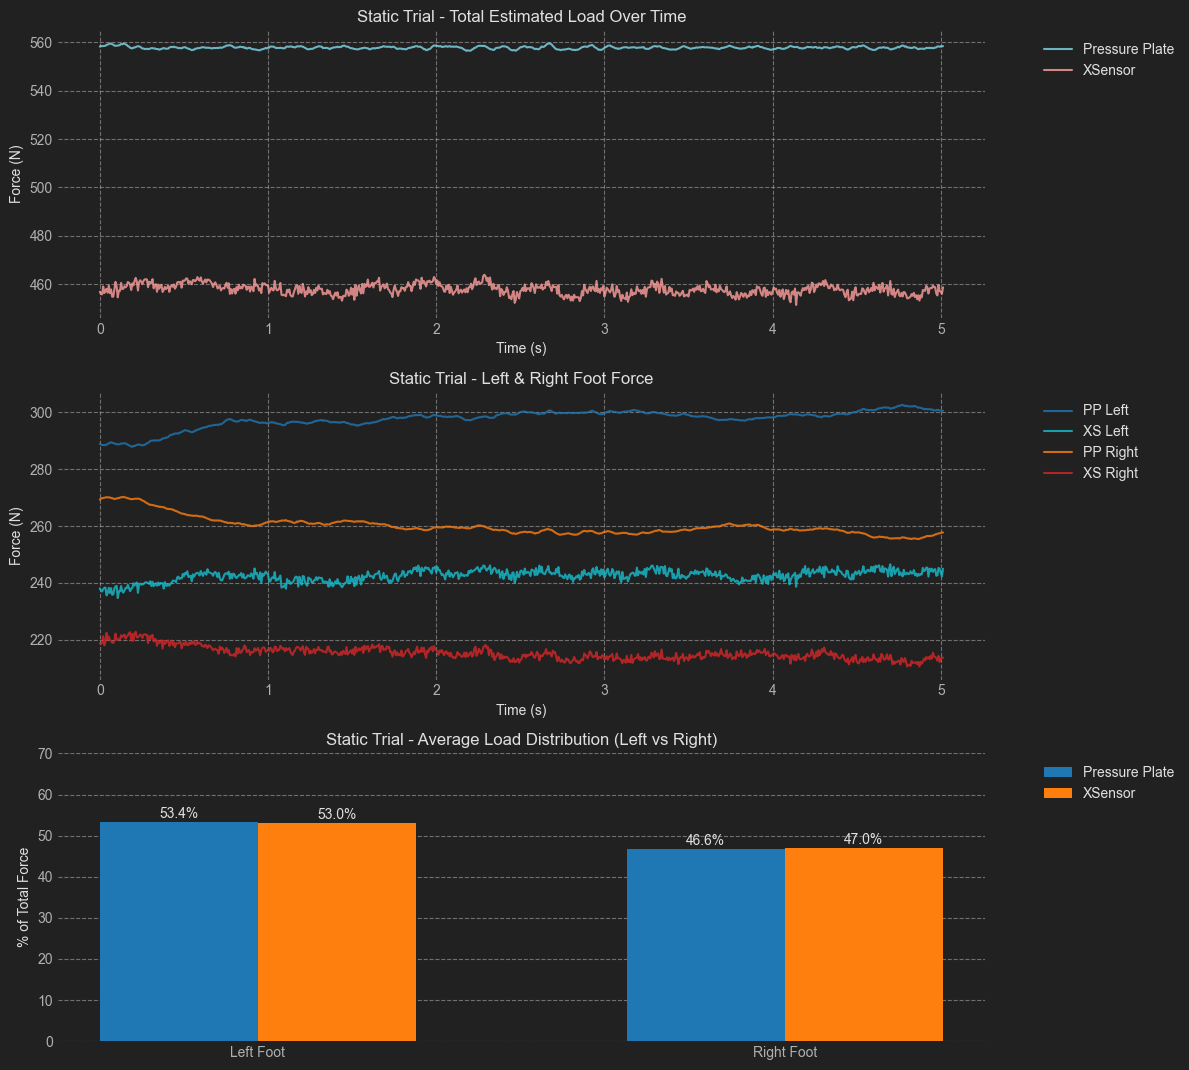

Avg Total Force  - PP: 557.7 N, XS: 457.9 N
XS reads 99.8 N lower (17.9%)
Left/Right Split - PP: 53.4% / 46.6%
                   XS: 53.0% / 47.0%


In [284]:
# STATIC TRIAL - PROCESSED COMPARISON
pp_static_aligned, xs_static_aligned = compare_trials(df_pp_static, df_xs_static, 'Static Trial')

### Weight Shift Trial - Aligned Comparison

Alignment: XS started earlier by 1.81s (272 samples)
Comparing 9.0s of overlapping data



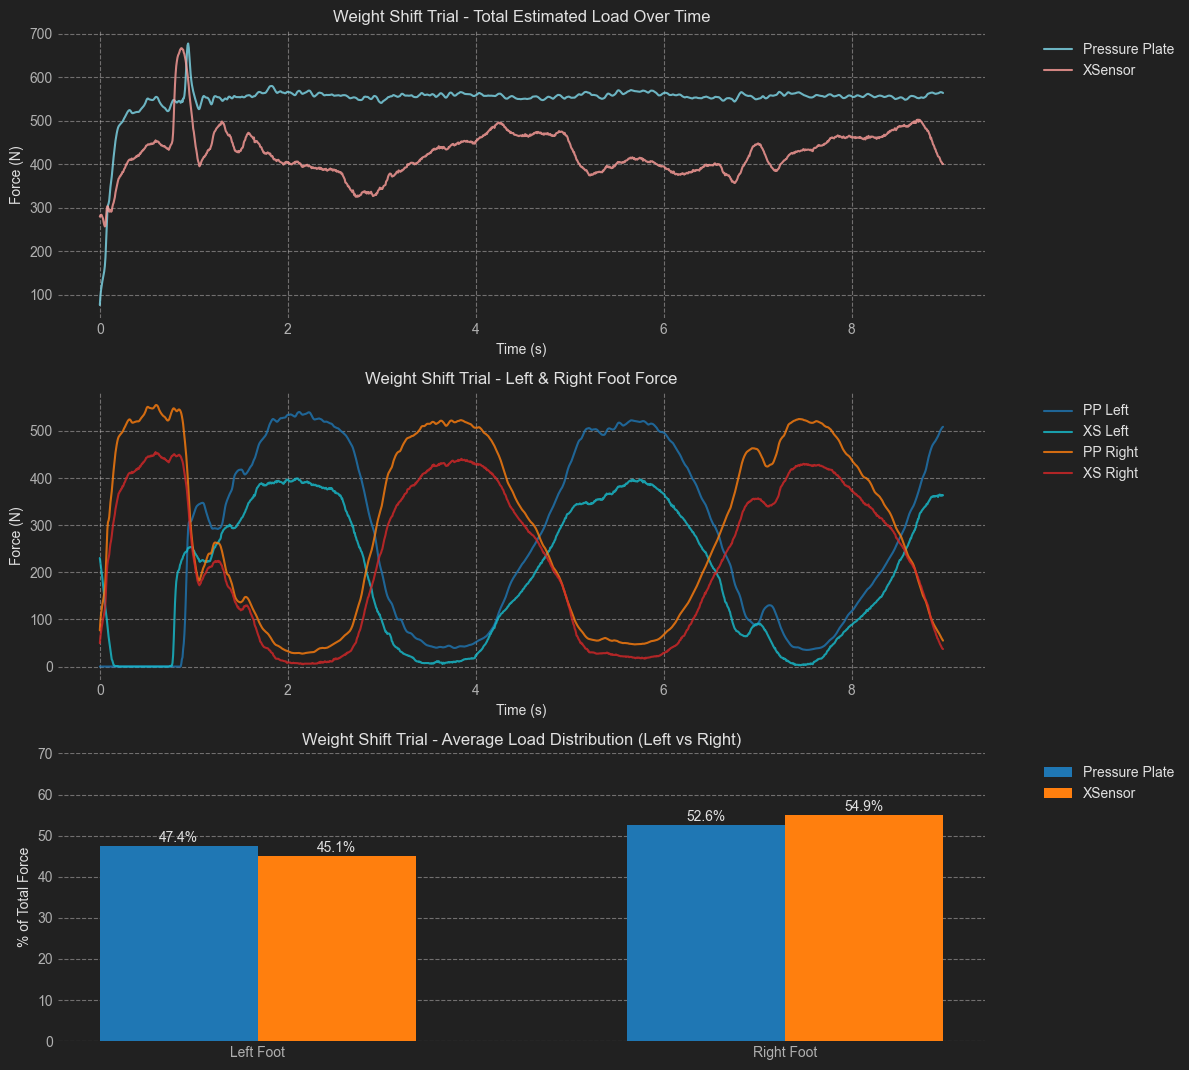

Avg Total Force  - PP: 550.3 N, XS: 425.8 N
XS reads 124.5 N lower (22.6%)
Left/Right Split - PP: 47.4% / 52.6%
                   XS: 45.1% / 54.9%


In [285]:
# WEIGHT SHIFT TRIAL - PROCESSED COMPARISON
pp_ws_aligned, xs_ws_aligned = compare_trials(df_pp_weight_shift, df_xs_weight_shift, 'Weight Shift Trial')

### Walking Trial - Aligned Comparison

Alignment: XS started earlier by 1.75s (263 samples)
Comparing 7.4s of overlapping data



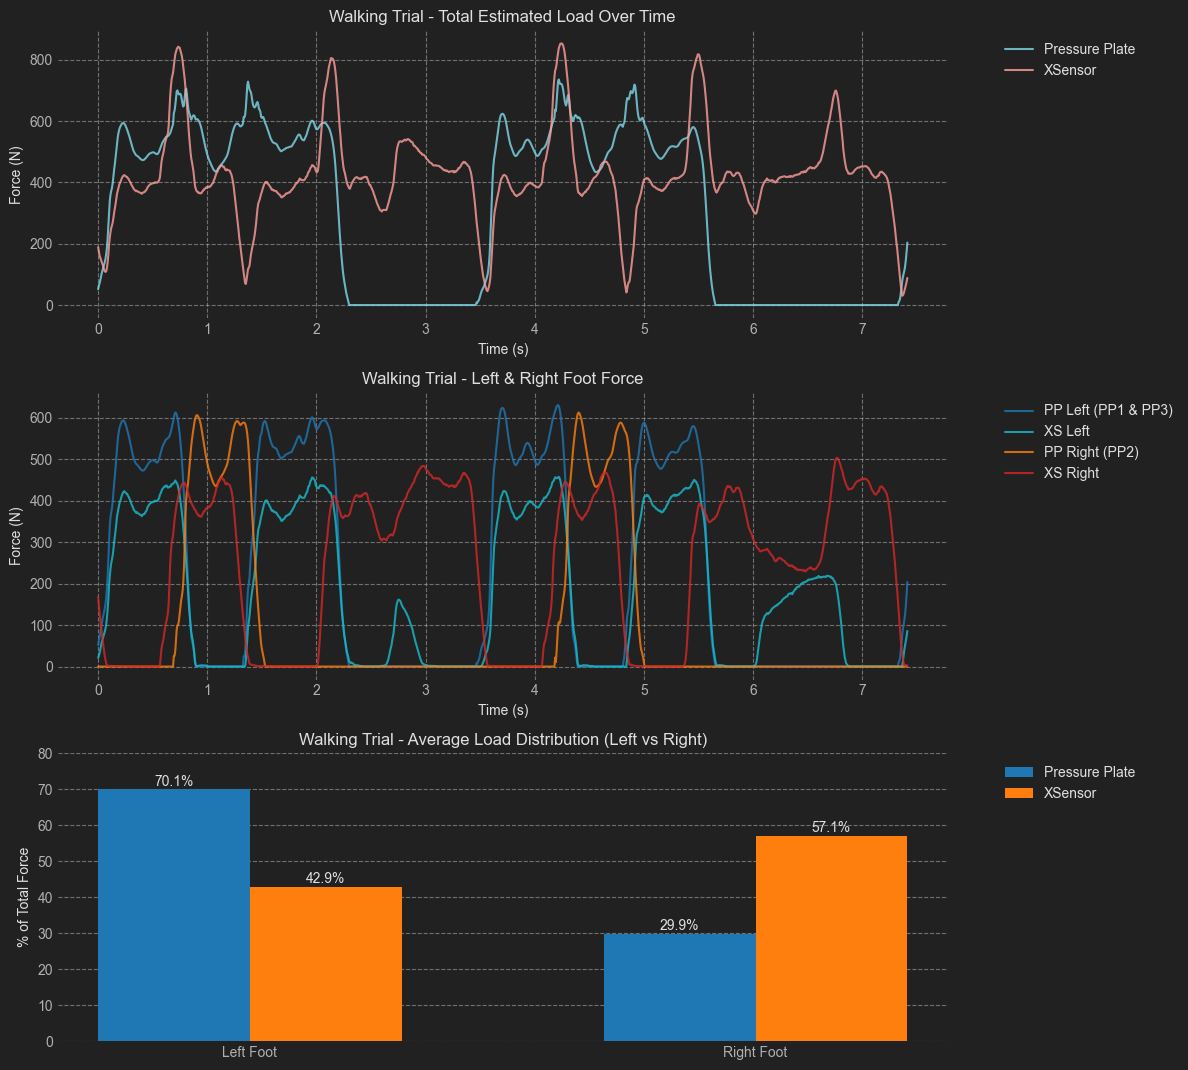

Avg Total Force  - PP: 308.7 N, XS: 422.9 N
XS reads 114.2 N higher (37.0%)
Left/Right Split - PP: 70.1% / 29.9%
                   XS: 42.9% / 57.1%

(Assuming PP1 & PP3 = Left Foot, PP2 = Right Foot)

--- Walking Signal Interpretation ---
Peaks = stance phase (foot on the ground bearing weight, heel strike through toe-off)
Troughs near zero = swing phase (foot in the air between steps)
Left foot (PP1 & PP3) shows 3 peaks: step onto PP1, PP3, then back to PP1
Right foot (PP2) shows 2 peaks: step onto PP2 forward, then PP2 returning
Dips in total force between peaks = weight transfer between feet
Plateau/pause in the middle = subject turning around on the plates


In [286]:
# WALKING TRIAL - PROCESSED COMPARISON
# Uses all 3 pressure plates: PP1 & PP3 combined as Foot A, PP2 as Foot B
pp_walking_aligned, xs_walking_aligned = compare_walking_trial(df_pp_walking, df_xs_walking, 'Walking Trial')

## Summary

In [287]:
# SUMMARY - LOAD DISTRIBUTION COMPARISON & FORCE DIFFERENCE

def trial_summary(pp, xs, name):
    """Calculate load distribution and force difference for one trial."""
    pp_total = pp['right_foot'] + pp['left_foot']
    xs_total = xs['right_foot'] + xs['left_foot']

    pp_left_pct = pp['left_foot'].mean() / pp_total.mean() * 100
    xs_left_pct = xs['left_foot'].mean() / xs_total.mean() * 100
    dist_diff = abs(pp_left_pct - xs_left_pct)

    force_diff = pp_total.mean() - xs_total.mean()
    force_diff_pct = force_diff / pp_total.mean() * 100

    return {
        'Trial': name,
        'PP Left %': pp_left_pct,
        'PP Right %': 100 - pp_left_pct,
        'XS Left %': xs_left_pct,
        'XS Right %': 100 - xs_left_pct,
        'Distribution Diff (pp)': dist_diff,
        'PP Avg Force (N)': pp_total.mean(),
        'XS Avg Force (N)': xs_total.mean(),
        'PP Higher By (N)': force_diff,
        'PP Higher By (%)': force_diff_pct,
    }

rows = [
    trial_summary(pp_static_aligned, xs_static_aligned, 'Static'),
    trial_summary(pp_ws_aligned, xs_ws_aligned, 'Weight Shift'),
    trial_summary(pp_walking_aligned, xs_walking_aligned, 'Walking'),
]
df_summary = pd.DataFrame(rows)

# --- Load Distribution Comparison ---
print("Load Distribution: How similar are left/right splits?\n")
for _, r in df_summary.iterrows():
    print(f"  {r['Trial']:>12}:  PP = {r['PP Left %']:.1f}% L / {r['PP Right %']:.1f}% R"
          f"   |   XS = {r['XS Left %']:.1f}% L / {r['XS Right %']:.1f}% R"
          f"   |   Diff = {r['Distribution Diff (pp)']:.1f} pp")

avg_dist_diff = df_summary['Distribution Diff (pp)'].mean()
print(f"\nAverage distribution difference across all trials: {avg_dist_diff:.1f} percentage points")
print(f"(Walking trial assumes PP1 & PP3 = Left, PP2 = Right)")

# --- Force Magnitude Comparison ---
print("\n\nForce Magnitude: How much higher does the Pressure Plate read?\n")
for _, r in df_summary.iterrows():
    direction = "higher" if r['PP Higher By (N)'] > 0 else "lower"
    print(f"  {r['Trial']:>12}:  PP = {r['PP Avg Force (N)']:.1f} N,  XS = {r['XS Avg Force (N)']:.1f} N"
          f"   ->   PP reads {abs(r['PP Higher By (N)']):.1f} N {direction} ({abs(r['PP Higher By (%)']):.1f}%)")

static_ws = df_summary[df_summary['Trial'] != 'Walking']
avg_higher = static_ws['PP Higher By (%)'].mean()
print(f"\nFor static & weight shift trials, PP reads ~{avg_higher:.0f}% higher than XS on average")

Load Distribution: How similar are left/right splits?

        Static:  PP = 53.4% L / 46.6% R   |   XS = 53.0% L / 47.0% R   |   Diff = 0.4 pp
  Weight Shift:  PP = 47.4% L / 52.6% R   |   XS = 45.1% L / 54.9% R   |   Diff = 2.3 pp
       Walking:  PP = 70.1% L / 29.9% R   |   XS = 42.9% L / 57.1% R   |   Diff = 27.1 pp

Average distribution difference across all trials: 9.9 percentage points
(Walking trial assumes PP1 & PP3 = Left, PP2 = Right)


Force Magnitude: How much higher does the Pressure Plate read?

        Static:  PP = 557.7 N,  XS = 457.9 N   ->   PP reads 99.8 N higher (17.9%)
  Weight Shift:  PP = 550.3 N,  XS = 425.8 N   ->   PP reads 124.5 N higher (22.6%)
       Walking:  PP = 308.7 N,  XS = 422.9 N   ->   PP reads 114.2 N lower (37.0%)

For static & weight shift trials, PP reads ~20% higher than XS on average


In [288]:

# Run all imports and data loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "#212121",
    "axes.facecolor": "#212121",
    "axes.edgecolor": "#706e6e",
    "axes.labelcolor": "#E0E0E0",
    "xtick.color": "#B0B0B0",
    "ytick.color": "#B0B0B0",
    "grid.color": "#c2bebe",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "text.color": "#E0E0E0",
    "axes.prop_cycle": plt.cycler(color=['#80daeb', '#ff9f9b', '#9df0a3', '#ffcc80'])
})

def import_pressure_plate_data(file_path):
    df = pd.read_csv(file_path, skiprows=4, usecols=[0, 3, 10])
    df.columns = ['sample', 'right_foot', 'left_foot']
    return df

def import_pressure_plate_walking_data(file_path):
    df = pd.read_csv(file_path, skiprows=4, usecols=[0, 3, 10, 17])
    df.columns = ['sample', 'pp1', 'pp2', 'pp3']
    return df

def import_xsensor_data(file_path):
    df = pd.read_csv(file_path, skiprows=4, usecols=[0, 3, 4])
    df.columns = ['sample', 'left_foot', 'right_foot']
    df[['left_foot', 'right_foot']] = df[['left_foot', 'right_foot']].round(2)
    return df

# Load all data
df_pp_static = import_pressure_plate_data('Pressure_Plate/PP_03_27_26_static.csv')
df_xs_static = import_xsensor_data('Xsensor/XS_03_27_26_static.csv')
df_pp_weight_shift = import_pressure_plate_data('Pressure_Plate/PP_03_27_26_weight_shift.csv')
df_xs_weight_shift = import_xsensor_data('Xsensor/XS_03_27_26_weight_shift.csv')
df_pp_walking = import_pressure_plate_walking_data('Pressure_Plate/PP_03_27_26_walking.csv')
df_xs_walking = import_xsensor_data('Xsensor/XS_03_27_26_walking.csv')

print("Data loaded.")
print(f"PP static: {len(df_pp_static)}, XS static: {len(df_xs_static)}")
print(f"PP weight shift: {len(df_pp_weight_shift)}, XS weight shift: {len(df_xs_weight_shift)}")
print(f"PP walking: {len(df_pp_walking)}, XS walking: {len(df_xs_walking)}")


Data loaded.
PP static: 12060, XS static: 1166
PP weight shift: 24000, XS weight shift: 2917
PP walking: 19900, XS walking: 1631
